# Plot Supplementary Figure S6A - Time-colored regrowth

This notebook generates a time-colored scatter plot showing when colonies appeared.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

Loaded 195 colonies
Time range: 2.25 - 17.92 hours
Figure saved: S6A_wt_time.pdf


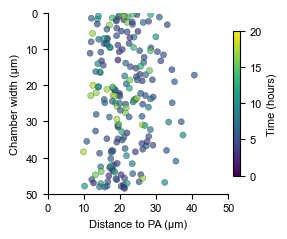

In [2]:
# ----------------------------------------------------------------------
# Data -----------------------------------------------------------------
colonies_df = pd.read_csv(
    '1_first_colonies_wt_merged.csv'
)

print(f"Loaded {len(colonies_df)} colonies")
print(f"Time range: {colonies_df['hours'].min():.2f} - {colonies_df['hours'].max():.2f} hours")

# ----------------------------------------------------------------------
# Constants -------------------------------------------------------------
pnas_fontsize = 8
fig_width, fig_height = 3, 2.5   # inches
replicate_markers = {'rep1': 'o', 'rep2': 'o', 'rep3': 'o'}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Determine plot range
max_coord = max(colonies_df['x_um'].max(), colonies_df['y_um'].max())
max_coord = np.ceil(max_coord / 10) * 10

# ----------------------------------------------------------------------
# Create figure ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Create colormap normalization based on hours
norm = Normalize(vmin=0, vmax=20)  # 0-20 hours
cmap = plt.cm.viridis

# Plot all colonies with time-based coloring
for rep, marker in replicate_markers.items():
    df_rep = colonies_df[colonies_df['replicate'] == rep]
    scatter = ax.scatter(df_rep['y_um'], df_rep['x_um'],   # swapped to rotate
                c=df_rep['hours'], cmap=cmap, norm=norm,
                marker=marker,
                s=20, alpha=0.7,
                edgecolors='k', linewidths=0.2)

# Formatting
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, max_coord)
ax.set_ylim(0, max_coord)
ax.set_xlabel('Distance to PA (µm)', fontsize=pnas_fontsize)
ax.set_ylabel('Chamber width (µm)', fontsize=pnas_fontsize)
ax.tick_params(axis='both', labelsize=pnas_fontsize)
ax.grid(False)

# Flip vertically
ax.invert_yaxis()

# Add colorbar on the right
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, 
                    orientation='vertical', pad=0.02, aspect=20, shrink=0.8)
cbar.set_label('Time (hours)', fontsize=pnas_fontsize)
cbar.ax.tick_params(labelsize=pnas_fontsize)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save
plt.tight_layout()
output_path = 'S6A_wt_time.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"Figure saved: {output_path}")

plt.show()